<h1 style="text-align: center;">Wine Clustering Analysis</h1>

## Project Purpose

The aim of this project is to explore **unsupervised machine learning** by grouping wine samples into meaningful clusters based on their numerical characteristics.

This notebook will focus on understanding the clustering workflow, including data inspection, preprocessing, cluster selection, model evaluation, and interpretation of the resulting groups.


-------------------
## Data Import

In [16]:
import pandas as pd
import numpy as np

In [5]:
data = pd.read_csv("wine-clustering.csv")

----------------
## EDA (Exploratory Data Analysis)

This section will perform an initial statistical inspection of the wine dataset to understand its structure, data types, missing values, duplicates, feature ranges, and overall distribution before moving to visualization and clustering.


In [6]:
data.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [7]:
data.shape

(178, 13)

In [8]:
data.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [18]:
data.nunique()

Alcohol                 126
Malic_Acid              133
Ash                      79
Ash_Alcanity             63
Magnesium                53
Total_Phenols            97
Flavanoids              132
Nonflavanoid_Phenols     39
Proanthocyanins         101
Color_Intensity         132
Hue                      78
OD280                   122
Proline                 121
dtype: int64

In [20]:
data.duplicated().sum()

np.int64(0)

### Initial Statistical EDA Evaluation

The dataset contains **178 rows and 13 numerical features**, with no missing values or duplicate records. The features have noticeably different numerical ranges, indicating that scaling will be necessary before applying distance-based clustering methods such as K-Means.

The descriptive statistics also suggest a few possible outliers in features such as `Ash_Alcanity`, `Color_Intensity`, and `Proline`. These values are not necessarily problematic, but they should be examined further through visualization before preprocessing decisions are made.

Overall, the dataset appears clean and suitable for clustering, with scaling and outlier inspection being the main considerations before modelling.


-------------
## Exploratory Data Analysis Using Visualization

This section will visually examine the distribution, spread, outliers, and relationships among the numerical features. Histograms and box plots will be used to inspect individual features, while a correlation heatmap and selected scatter plots will help identify relationships and possible grouping patterns that may be relevant for clustering.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

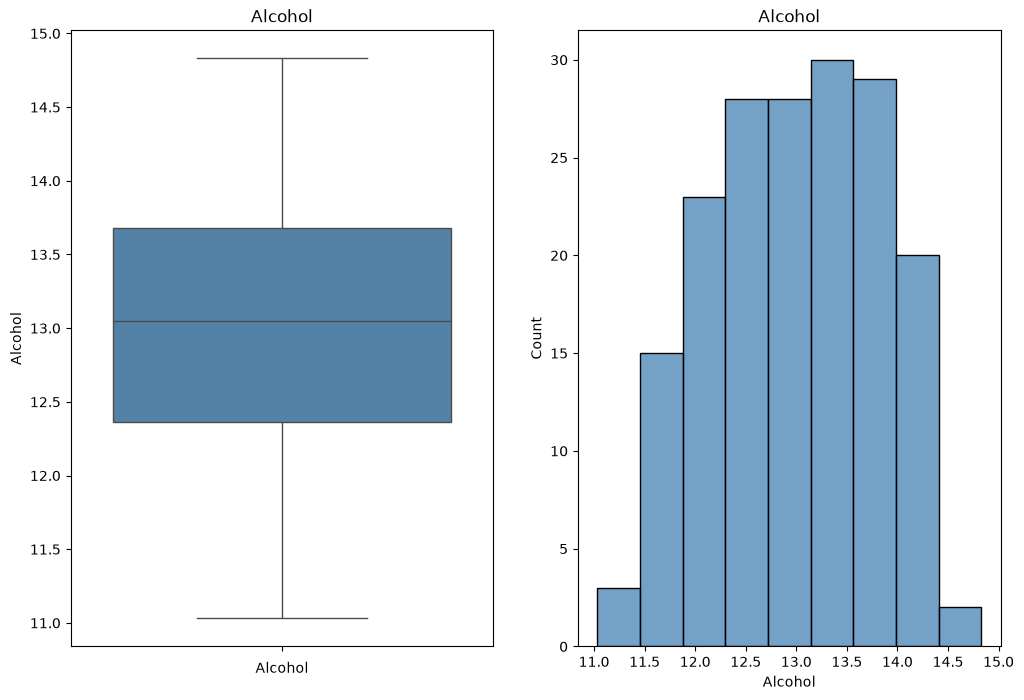

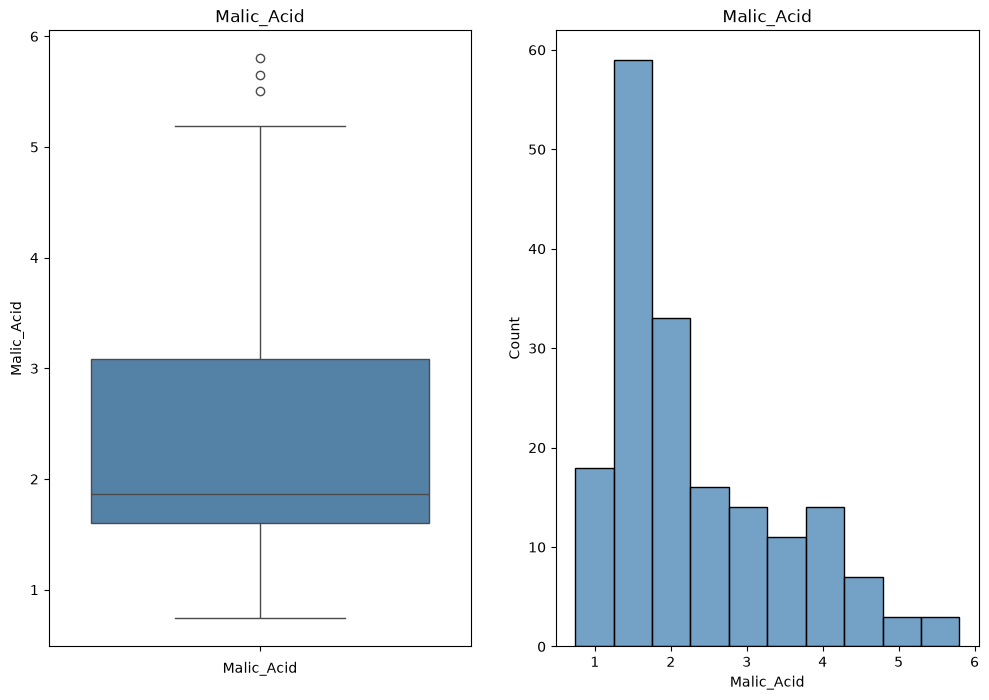

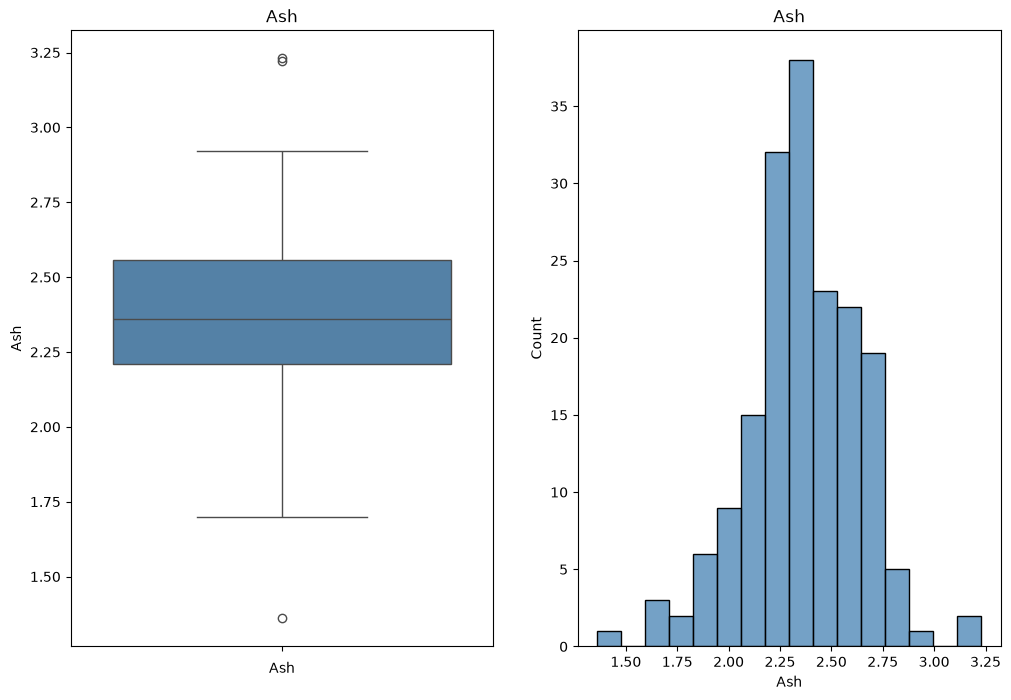

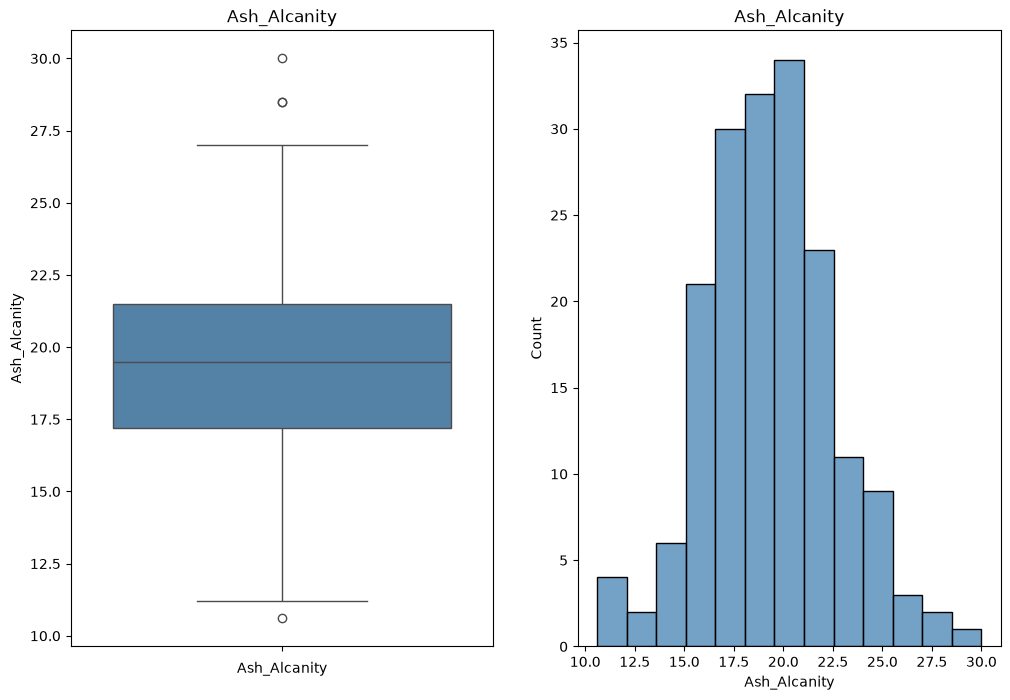

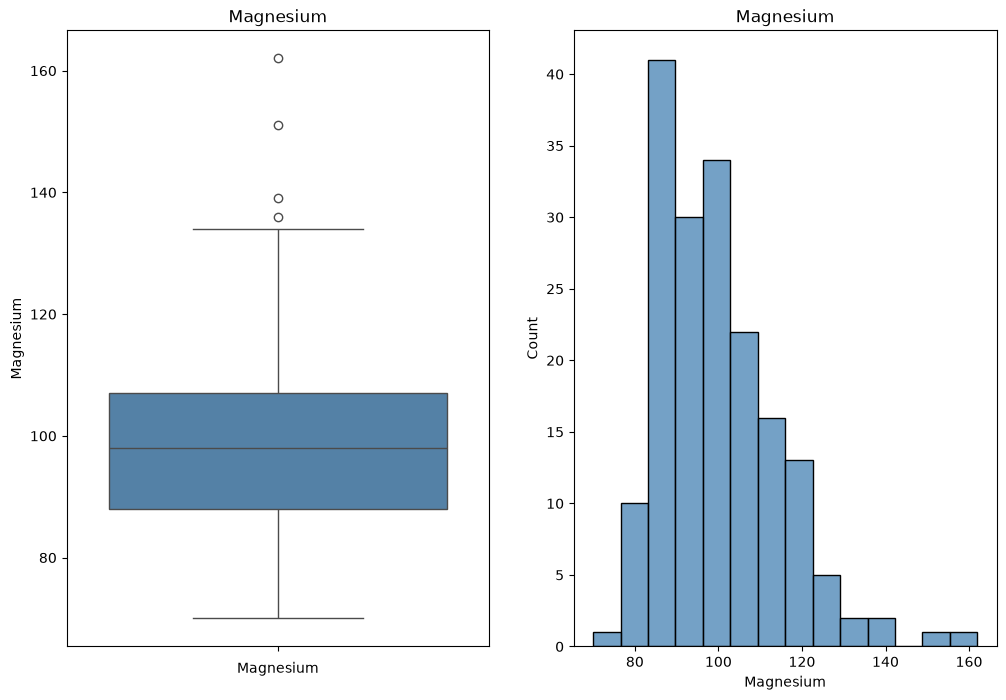

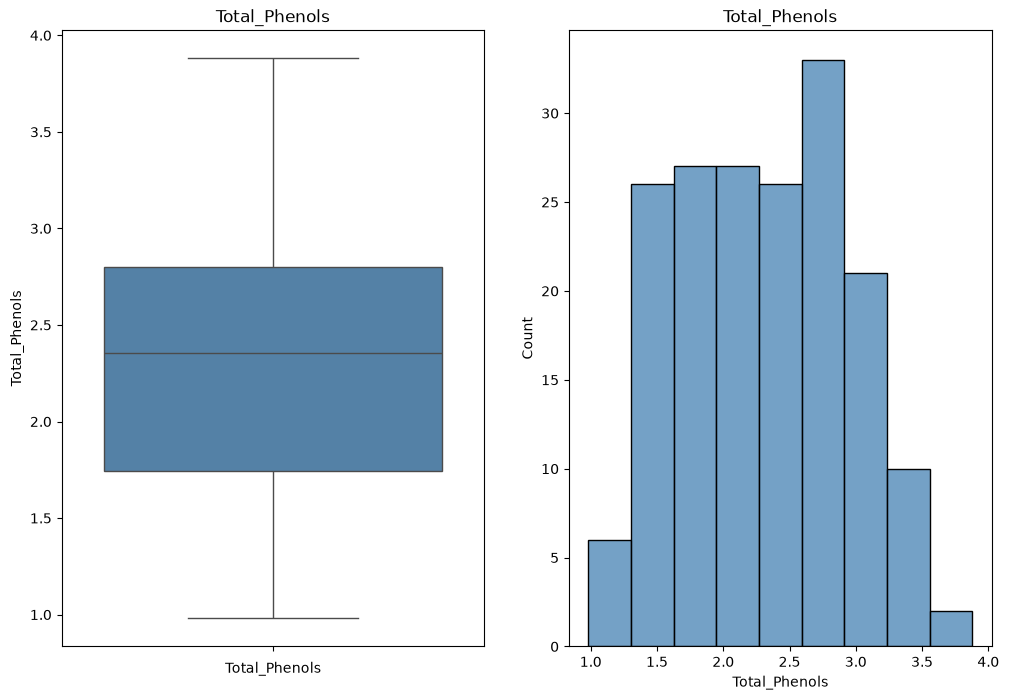

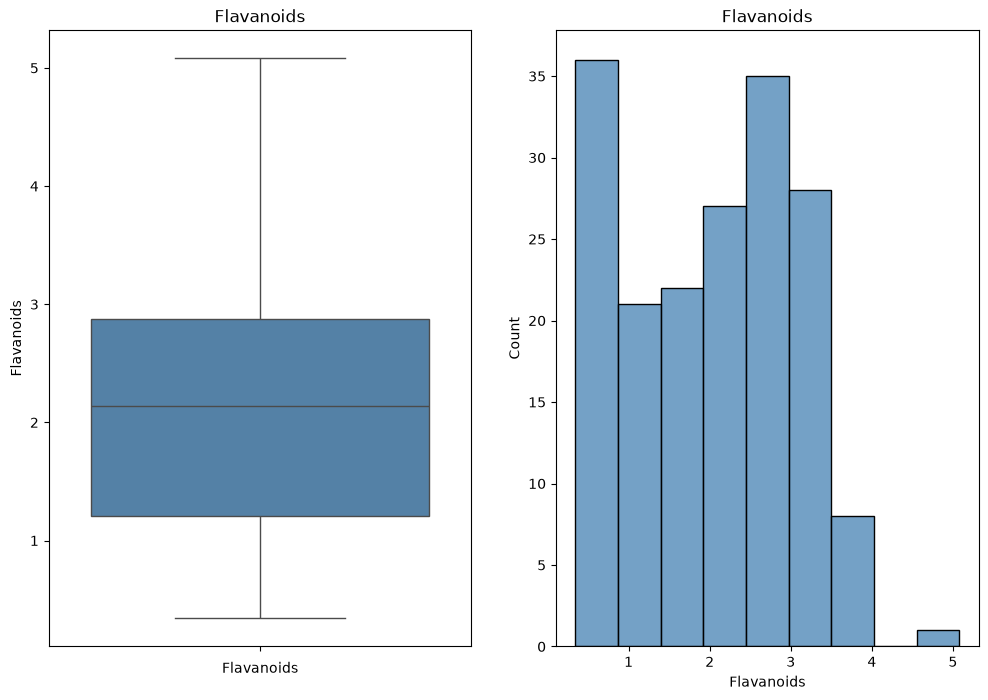

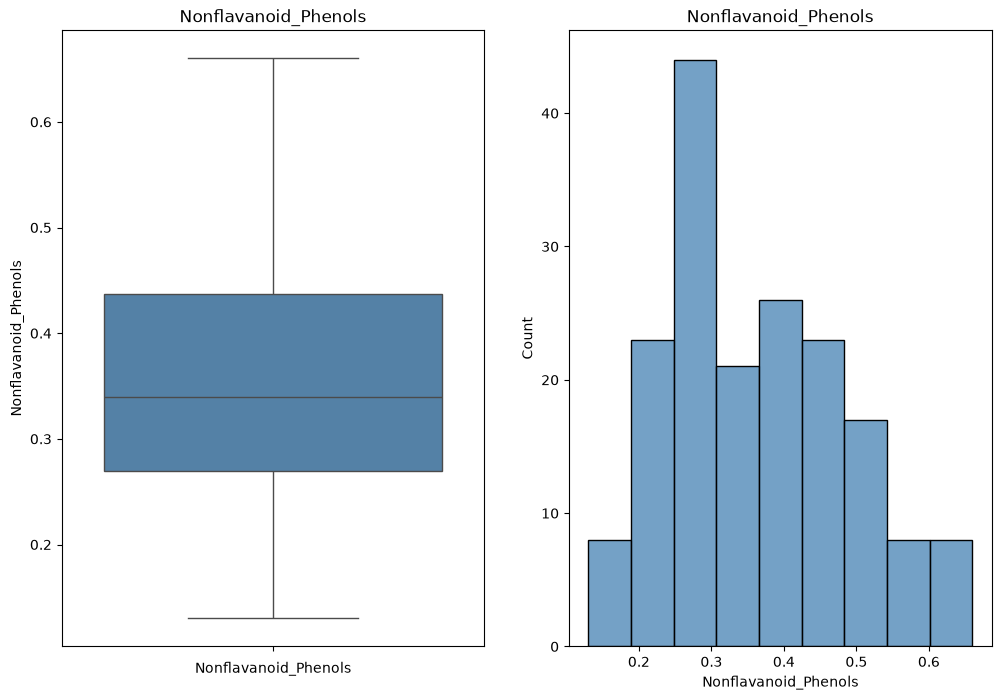

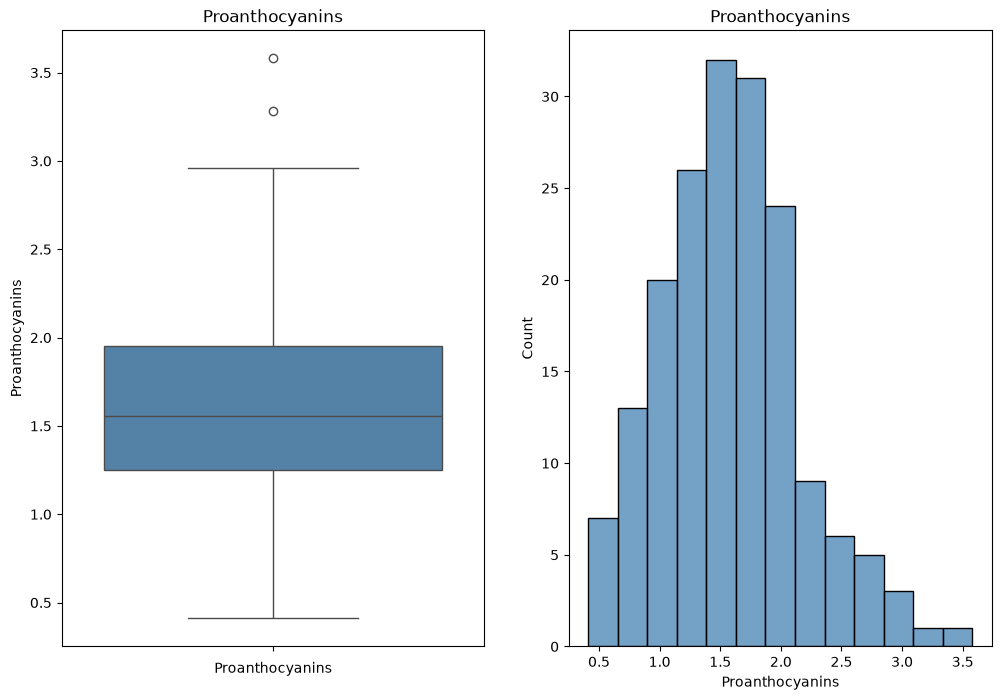

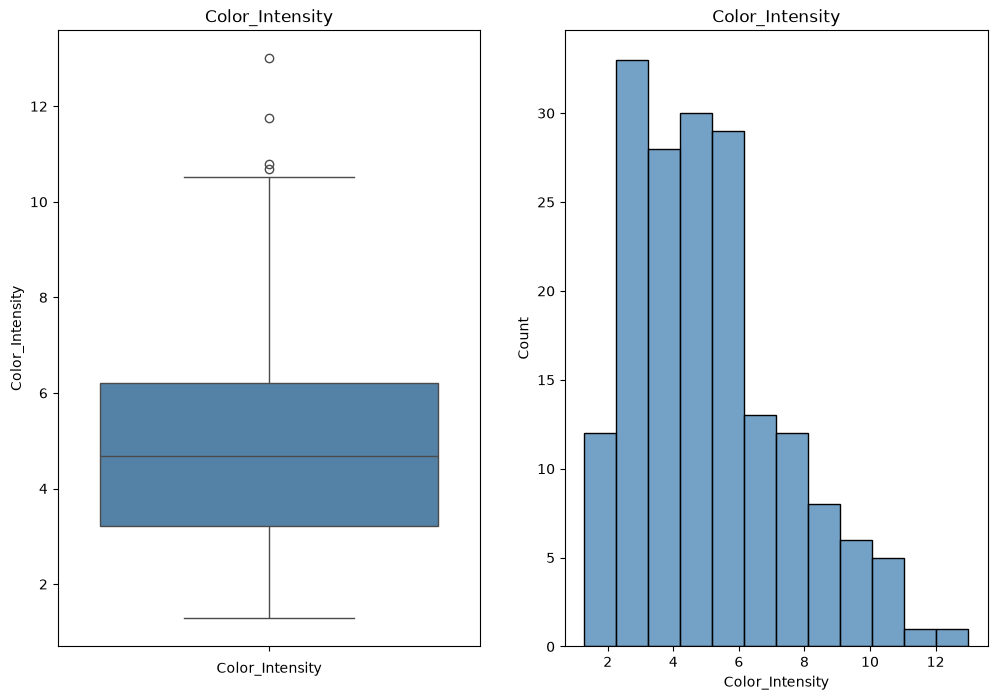

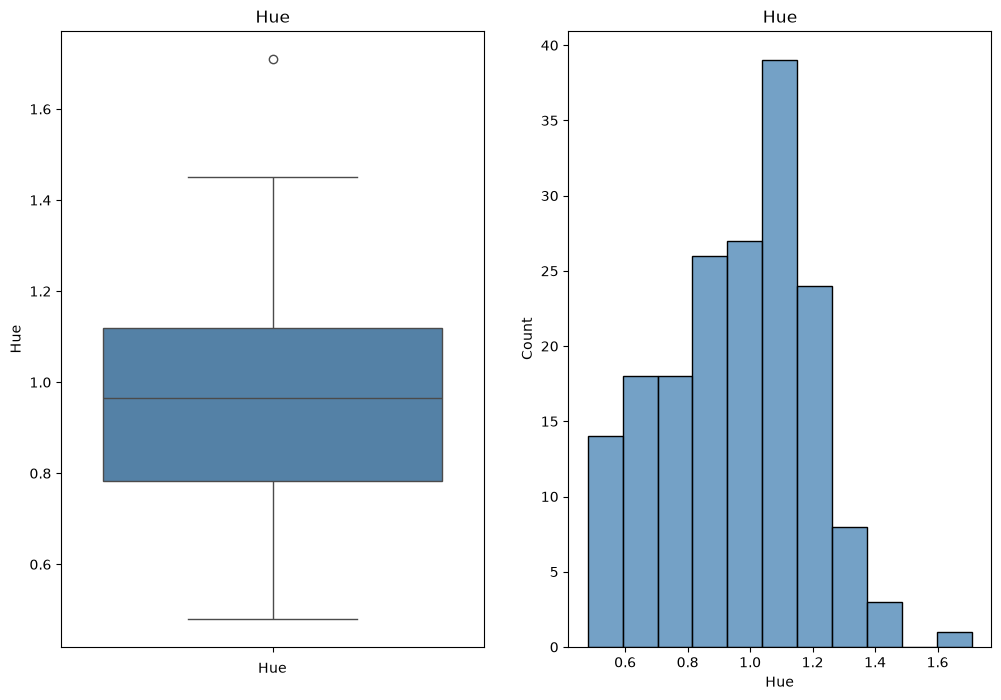

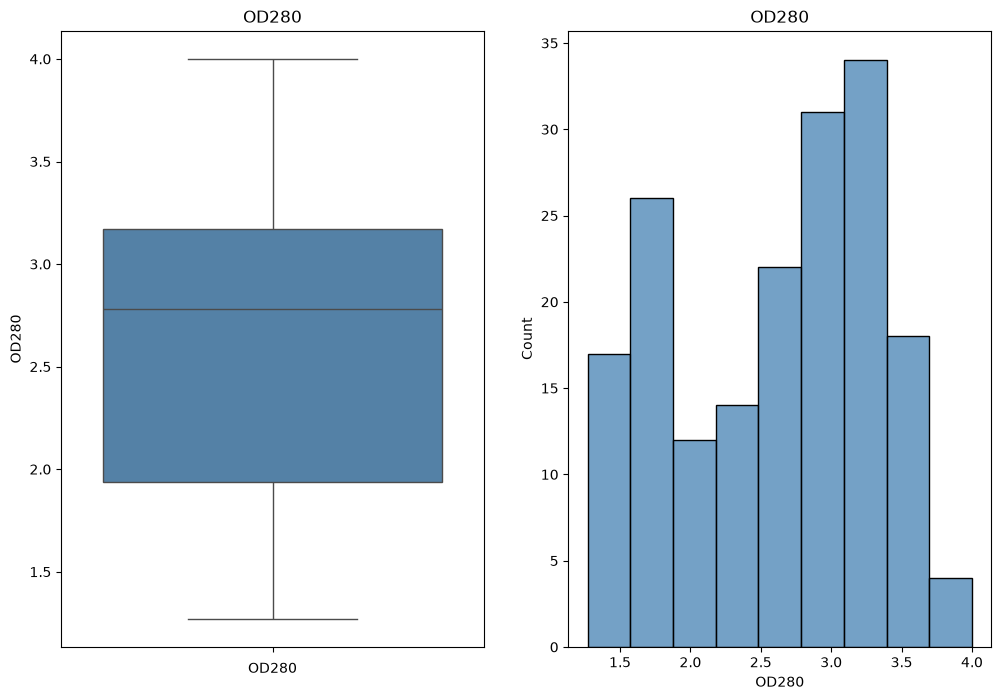

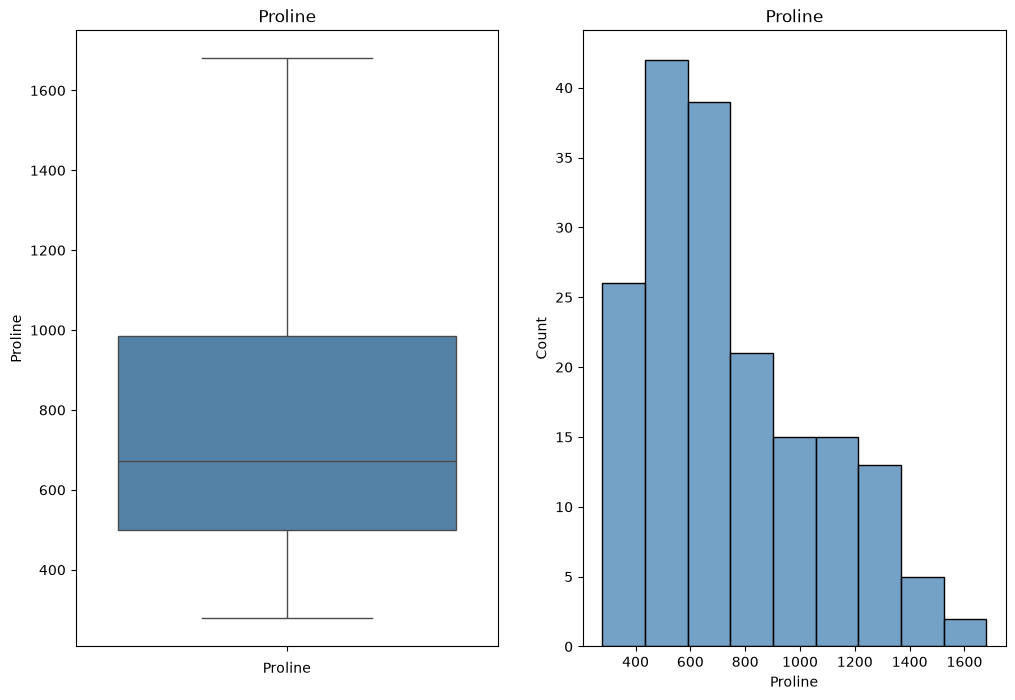

In [25]:
for column in data.columns.to_list():
    fig = plt.figure(figsize=(12,8))
    ax0 = fig.add_subplot(1,2,1)
    ax1 = fig.add_subplot(1,2,2)

    sns.boxplot(data=data, y=column, color="steelblue", ax=ax0)
    ax0.set_title(column)
    ax0.set_xlabel(column)

    sns.histplot(data=data, x=column, color="steelblue", ax=ax1)
    ax1.set_title(column)
    ax1.set_xlabel(column)

    plt.show()


### Visualization Evaluation

#### Clean distributions with no obvious outliers
- Alcohol
- Total_Phenols
- Nonflavanoid_Phenols

#### Mostly balanced distributions with a few outliers
- Ash
- Ash_Alcanity
- Hue

#### Right-skewed distributions with upper-end outliers
- Malic_Acid
- Magnesium
- Proanthocyanins
- Color_Intensity

#### Right-skewed distribution with no obvious outliers
- Proline

#### Irregular / non-normal distributions
- Flavanoids
- OD280

### Overall Observation

The features show different patterns of skewness, outlier presence, and numerical scale. These differences should be considered when selecting an appropriate scaling method before clustering.

------------------------------------------------
## Correlation Analysis

This section will examine the relationships between the numerical features using a **correlation heatmap**. The aim is to identify features that have strong positive or negative relationships and to understand which variables tend to change together.

This analysis can also help identify highly correlated features that may contain similar or overlapping information before moving toward clustering.


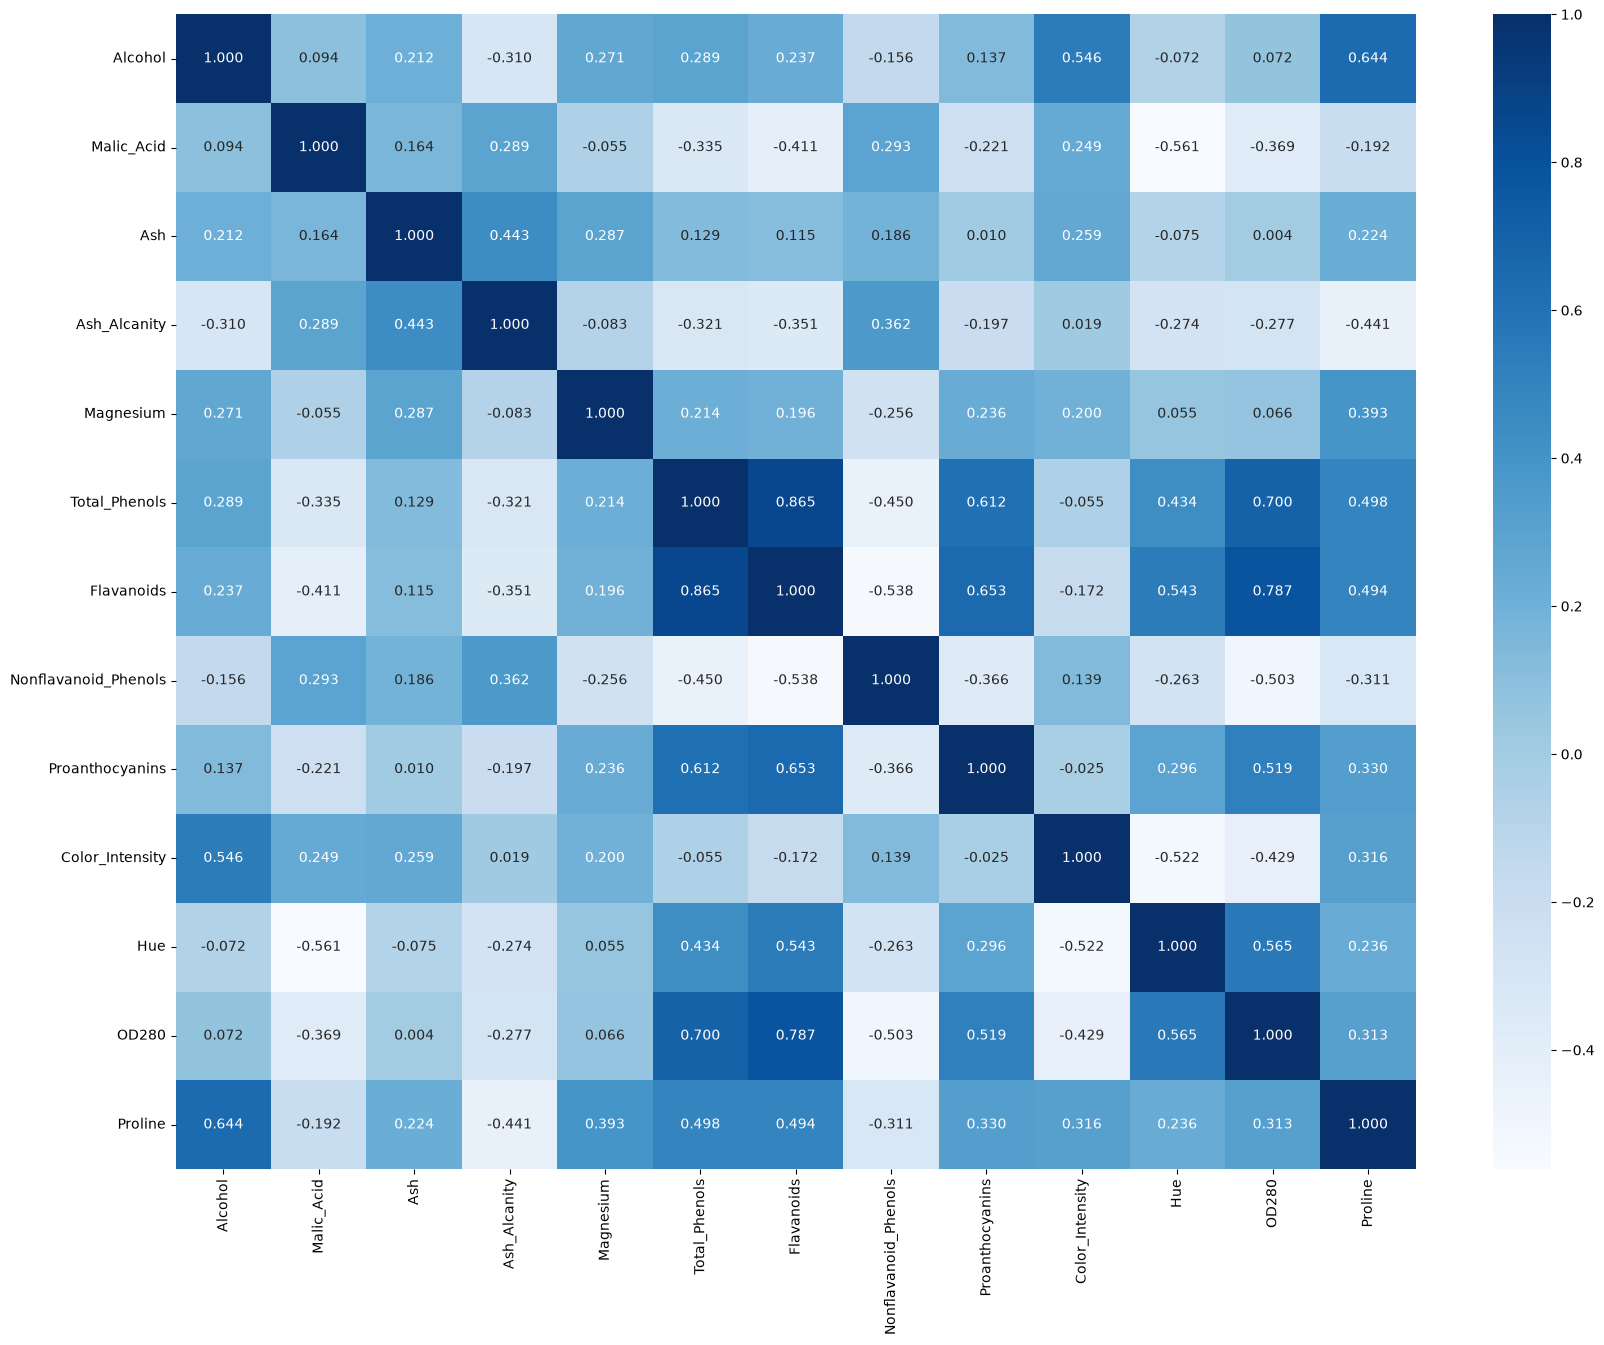

In [27]:
plt.figure(figsize=(20,15))
sns.heatmap(data=data.corr(), annot=True, fmt=".3f", cmap="Blues")
plt.show()

### Correlation Evaluation

Most features do not show extremely high correlation, suggesting that they retain distinct information. The strongest relationship is between Total_Phenols and Flavanoids, with a few other moderate relationships also present.

Overall, there are no near-duplicate features based on correlation alone.